# SPOC vs TESSCut Aperture / Crowding Control

## Analysis scope

This notebook tests whether local stellar crowding and TESSCut aperture size are associated with the matched SPOC--TESSCut provenance effect.

The primary performance test measures the SPOC minus TESSCut held-out classification gap across crowding quartiles. Separate association tests measure whether SPOC--TESSCut feature disagreement varies with crowding or aperture size.

The notebook reproduces the canonical matched-star baseline using 39 predictors without `ProvenanceScore`, identical matched stars and train/test assignments, median imputation, a 500-tree Random Forest with `class_weight="balanced_subsample"`, and `random_state=42`.

### Interpretation boundary

The analysis tests association rather than causality. Gaia G-band flux is used as a crowding proxy and is not a calibrated TESS contamination fraction. The TESSCut threshold aperture can be irregular, so its area-equivalent radius is an aperture-size proxy rather than an exact geometric representation. Crowding and aperture size are therefore analyzed separately, with a combined crowding-times-aperture quantity retained as a secondary diagnostic.

The executed analysis contains 506 matched stars and a 152-star held-out test set. Of the held-out stars, 148 have finite values for the primary crowding metric and contribute to the crowding-quartile performance analysis.

## 1. Configuration

The analysis uses:

- Gaia search radius: **84 arcsec (~4 TESS pixels)**
- TESS pixel scale approximation: **21 arcsec/pixel**
- Gaia target-match radius: **2 arcsec**
- Gaia G magnitude limit: **20.5**
- Gaia batch size: **50 targets**
- local worker count: **24**

Local per-star aperture calculations and crowding-metric summaries use multithreading. Gaia TAP batches remain sequential because they share one transient upload file and use an external asynchronous service. The Gaia stage is restartable through its cumulative parquet cache.

In [1]:
from __future__ import annotations

import json
import math
import os
import time
import traceback
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.table import Table
from astroquery.gaia import Gaia
from scipy.stats import spearmanr, mannwhitneyu

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

DATA_ROOT = Project_Root / "data_pipeline/SPOC_TESSCutCache"

SPOC_TESSCut_META_CONSOLIDATE_FILE_QC = (
    DATA_ROOT / "SPOC_TESSCut_Metadata_Consolidated_QC.parquet"
)

# Existing controlled feature table used by the SPOC-vs-TESSCut RF experiment.
SPOC_TESSCut_FEATURE_FILE_QC = (
    DATA_ROOT / "SPOC_TESSCut_features_QC.parquet"
)

Project_Root = Path(os.environ.get("Project_Root", "/data/projects/TESS-research"))

OUTPUT_DIR = Path(
    str(Project_Root / "summary" / "spoc_tesscut_crowding")
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Single cumulative Gaia query parquet used for both progress tracking
# and Gaia source rows. No new per-batch parquet cache files are created.
TARGET_TABLE_FILE = OUTPUT_DIR / "unique_targets.parquet"
GAIA_NEIGHBORS_FILE = OUTPUT_DIR / "gaia_neighbors.parquet"

# Read-only legacy location from the previous implementation.
# It is used only once to recover already completed work if the new
# cumulative parquet does not yet exist.
LEGACY_GAIA_BATCH_DIR = OUTPUT_DIR / "gaia_batches"

# One transient upload file, overwritten for each Gaia request.
GAIA_UPLOAD_TEMP_FILE = OUTPUT_DIR / "_gaia_upload_current.xml"
CROWDING_METRICS_FILE = OUTPUT_DIR / "crowding_metrics.parquet"
RF_TEST_RESULTS_FILE = OUTPUT_DIR / "rf_test_predictions_with_crowding.parquet"

TESS_PIXEL_SCALE_ARCSEC = 21.0
GAIA_QUERY_RADIUS_ARCSEC = 84.0
GAIA_G_MAX = 20.5
GAIA_TARGET_MATCH_RADIUS_ARCSEC = 2.0
GAIA_BATCH_SIZE = 50

# launch_job_async(..., background=True) returns immediately, allowing
# this notebook to poll the job and stop waiting if the server stalls.
GAIA_QUERY_TIMEOUT_MINUTES = 45.0
GAIA_POLL_SECONDS = 10.0

# Set False when you only want to read the cumulative parquet and run
# the downstream analysis without making new Gaia queries.
RUN_GAIA_QUERY = True

TARGET_COLUMN = "family"
RANDOM_STATE = 42
TEST_SIZE = 0.30
MAX_WORKERS = 24

# Canonical representative SPOC--TESSCut split (seed 42).
# Accuracy references are exact correct-count ratios. Balanced-accuracy
# references are manuscript values rounded to three decimals; the
# 5e-4 tolerance allows only that rounding difference.
CANONICAL_MATCHED_STAR_COUNT = 506
CANONICAL_TEST_STAR_COUNT = 152
CANONICAL_SPOC_ACCURACY = 116 / 152
CANONICAL_SPOC_BALANCED_ACCURACY = 0.571
CANONICAL_TESSCUT_ACCURACY = 96 / 152
CANONICAL_TESSCUT_BALANCED_ACCURACY = 0.387
CANONICAL_BASELINE_TOLERANCE = 5e-4

print("Metadata:", SPOC_TESSCut_META_CONSOLIDATE_FILE_QC)
print("Features:", SPOC_TESSCut_FEATURE_FILE_QC)
print("Output:", OUTPUT_DIR)
print("RUN_GAIA_QUERY =", RUN_GAIA_QUERY)
print("MAX_WORKERS =", MAX_WORKERS)


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
Metadata: /data/projects/TESS-research/data_pipeline/SPOC_TESSCutCache/SPOC_TESSCut_Metadata_Consolidated_QC.parquet
Features: /data/projects/TESS-research/data_pipeline/SPOC_TESSCutCache/SPOC_TESSCut_features_QC.parquet
Output: /data/projects/TESS-research/summary/spoc_tesscut_crowding
RUN_GAIA_QUERY = True
MAX_WORKERS = 24


## 2. Load and validate the matched metadata

The input contains matched SPOC and TESSCut representations. The validation retains clean one-to-one pairs and requires the two representations of each VSX object to have the same family label.

In [2]:
def normalize_provenance(value):
    text = str(value).strip().upper()
    if text == "SPOC":
        return "SPOC"
    if text in {"TESSCUT", "TESS CUT"}:
        return "TESSCut"
    return str(value).strip()


def resolve_provenance_column(df):
    for c in ["Provenance", "provenance", "Source", "source", "author"]:
        if c in df.columns:
            return c
    raise KeyError("Could not find provenance column.")


def resolve_coordinate_columns(df):
    for ra, dec in [
        ("raDeg", "decDeg"),
        ("RA", "DEC"),
        ("ra", "dec"),
        ("RA_deg", "DEC_deg"),
    ]:
        if ra in df.columns and dec in df.columns:
            return ra, dec
    raise KeyError("Could not locate target RA/Dec columns.")


meta = pd.read_parquet(SPOC_TESSCut_META_CONSOLIDATE_FILE_QC)

for required in ["VSXId", TARGET_COLUMN]:
    if required not in meta.columns:
        raise ValueError(f"Missing required metadata column: {required}")

prov_col = resolve_provenance_column(meta)
ra_col, dec_col = resolve_coordinate_columns(meta)

meta = meta.copy()
meta["VSXId"] = meta["VSXId"].astype(str)
meta["_Provenance"] = meta[prov_col].map(normalize_provenance)

pair_counts = (
    meta[meta["_Provenance"].isin(["SPOC", "TESSCut"])]
    .groupby(["VSXId", "_Provenance"])
    .size()
    .unstack(fill_value=0)
)

valid_ids = pair_counts.index[
    (pair_counts.get("SPOC", 0) == 1)
    & (pair_counts.get("TESSCut", 0) == 1)
]

paired_meta = meta[meta["VSXId"].isin(valid_ids)].copy()

spoc_meta = (
    paired_meta[paired_meta["_Provenance"] == "SPOC"]
    .set_index("VSXId", drop=False)
    .sort_index()
)
tc_meta = (
    paired_meta[paired_meta["_Provenance"] == "TESSCut"]
    .set_index("VSXId", drop=False)
    .sort_index()
)

common_ids = spoc_meta.index.intersection(tc_meta.index)
spoc_meta = spoc_meta.loc[common_ids]
tc_meta = tc_meta.loc[common_ids]

mismatch = (
    spoc_meta[TARGET_COLUMN].astype(str)
    != tc_meta[TARGET_COLUMN].astype(str)
)
if mismatch.any():
    raise ValueError(f"Family mismatch for {int(mismatch.sum())} matched stars.")

print(f"Input metadata rows: {len(meta):,}")
print(f"Valid one-to-one matched stars: {len(common_ids):,}")
display(
    spoc_meta[TARGET_COLUMN]
    .value_counts()
    .rename_axis("family")
    .reset_index(name="matched_stars")
)

Input metadata rows: 1,012
Valid one-to-one matched stars: 506


,family,matched_stars
0,LONG_PERIOD,117
1,CV,114
2,YSO,92
3,CEPHEID,64
4,DSCT_SXPHE,51
5,ELLIPSOIDAL_ROT,29
6,XRAY,20
7,ECLIPSING,14
8,RRLYR,5


## 3. Recover TESSCut aperture size from `extractionMetadata`

The original TESSCut extractor stored one aperture-pixel count per successfully extracted sector.

For each star, this analysis calculates the minimum, median, mean, and maximum aperture size and an area-equivalent circular radius:

$$
r_{\rm eq} = 21'' \sqrt{\frac{N_{\rm pix}}{\pi}}.
$$

This radius summarizes aperture area; the underlying threshold mask can be irregular.

In [3]:
def parse_jsonish(value):
    if isinstance(value, dict):
        return dict(value)
    if isinstance(value, str):
        try:
            parsed = json.loads(value)
            return parsed if isinstance(parsed, dict) else {}
        except Exception:
            return {}
    return {}


def numeric_list(value):
    if not isinstance(value, (list, tuple, np.ndarray)):
        return []
    out = []
    for item in value:
        try:
            x = float(item)
        except Exception:
            continue
        if np.isfinite(x):
            out.append(x)
    return out


def aperture_stats(row):
    emeta = parse_jsonish(row.get("extractionMetadata"))
    counts = numeric_list(emeta.get("aperturePixelCounts", []))

    result = {
        "TESSCutApertureSectorCount": len(counts),
        "TESSCutAperturePixelsMin": np.nan,
        "TESSCutAperturePixelsMedian": np.nan,
        "TESSCutAperturePixelsMean": np.nan,
        "TESSCutAperturePixelsMax": np.nan,
        "TESSCutEquivalentApertureRadiusArcsec": np.nan,
        "TESSCutExtractionMethod": emeta.get("extractionMethod"),
        "TESSCutCutoutSize": str(emeta.get("cutoutSize")),
    }

    if counts:
        a = np.asarray(counts, dtype=float)
        med = float(np.median(a))
        result.update({
            "TESSCutAperturePixelsMin": float(np.min(a)),
            "TESSCutAperturePixelsMedian": med,
            "TESSCutAperturePixelsMean": float(np.mean(a)),
            "TESSCutAperturePixelsMax": float(np.max(a)),
            "TESSCutEquivalentApertureRadiusArcsec": (
                TESS_PIXEL_SCALE_ARCSEC * math.sqrt(med / math.pi)
            ),
        })
    return result


def build_aperture_row(vsx_id, row):
    return {"VSXId": str(vsx_id), **aperture_stats(row)}


print(
    f"Computing aperture summaries for {len(tc_meta):,} stars "
    f"with up to {MAX_WORKERS} workers."
)

aperture_rows = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    future_map = {
        executor.submit(build_aperture_row, vsx_id, row): str(vsx_id)
        for vsx_id, row in tc_meta.iterrows()
    }
    for future in as_completed(future_map):
        aperture_rows.append(future.result())

aperture_df = (
    pd.DataFrame(aperture_rows)
    .sort_values("VSXId")
    .set_index("VSXId", drop=False)
)

print("Aperture metadata coverage:")
display(
    aperture_df[
        [
            "TESSCutApertureSectorCount",
            "TESSCutAperturePixelsMedian",
            "TESSCutEquivalentApertureRadiusArcsec",
        ]
    ].describe()
)

Computing aperture summaries for 506 stars with up to 24 workers.
Aperture metadata coverage:


,TESSCutApertureSectorCount,TESSCutAperturePixelsMedian,TESSCutEquivalentApertureRadiusArcsec
count,506.000000,506.000000,506.000000
mean,3.213439,30.070158,58.834740
std,4.360704,23.272695,27.587419
min,1.000000,1.000000,11.847981
25%,1.000000,9.000000,35.543944
50%,2.000000,24.000000,58.043017
75%,4.000000,51.875000,85.334071
max,42.000000,90.000000,112.399819


## 4. Build one Gaia-query target per matched star

SPOC and TESSCut represent the same matched object, so Gaia is queried once per `VSXId`. The VSX RA/Dec stored in the matched metadata defines the target coordinate.

In [4]:
target_rows = []

for target_index, vsx_id in enumerate(common_ids):
    qrow = spoc_meta.loc[vsx_id]
    trow = tc_meta.loc[vsx_id]

    ra = pd.to_numeric(qrow.get(ra_col), errors="coerce")
    dec = pd.to_numeric(qrow.get(dec_col), errors="coerce")

    if not (np.isfinite(ra) and np.isfinite(dec)):
        ra = pd.to_numeric(trow.get(ra_col), errors="coerce")
        dec = pd.to_numeric(trow.get(dec_col), errors="coerce")

    target_rows.append({
        "target_index": target_index,
        "VSXId": vsx_id,
        "family": str(qrow[TARGET_COLUMN]),
        "ra_deg": ra,
        "dec_deg": dec,
    })

targets = pd.DataFrame(target_rows)

bad = ~(np.isfinite(targets["ra_deg"]) & np.isfinite(targets["dec_deg"]))
if bad.any():
    raise ValueError(f"{int(bad.sum())} matched stars have invalid coordinates.")

targets.to_parquet(TARGET_TABLE_FILE, index=False)

print(f"Unique Gaia targets: {len(targets):,}")
display(targets.head())

Unique Gaia targets: 506


,target_index,VSXId,family,ra_deg,dec_deg
0,0,000-BBB-003,LONG_PERIOD,0.027333,25.886472
1,1,000-BBB-284,LONG_PERIOD,3.041583,-17.938278
2,2,000-BBB-752,YSO,7.877833,61.980833
3,3,000-BBC-530,DSCT_SXPHE,18.189290,-37.856470
4,4,000-BBD-866,CV,36.479310,37.568150


## 5. Restartable bulk Gaia DR3 neighborhood query

The Gaia query uses a single cumulative cache, `gaia_neighbors.parquet`, for both returned sources and restart status. The implementation does not create new `gaia_neighbors_batch_XXXX.parquet` files.

On each execution, the query stage rebuilds the target list, reads the cumulative cache, identifies targets with successful status records, and queries only targets not already completed. Each successful batch is appended and the cumulative parquet is rewritten immediately. A completed target receives a status row even when Gaia returns zero sources.

The default batch contains 50 targets. Gaia jobs run asynchronously and are polled with a 45-minute timeout. Failed or timed-out targets are not marked complete and remain eligible for a later restart.

Legacy SPOC batch files can be imported when the cumulative cache does not yet exist. Legacy source-only files cannot establish that a successfully queried target returned zero sources, so such targets are queried again.

The catalog search retrieves Gaia DR3 sources within `GAIA_QUERY_RADIUS_ARCSEC` subject to `phot_g_mean_mag <= GAIA_G_MAX`. Gaia G flux is used only as a crowding proxy and is not a calibrated TESS contamination fraction.

In [5]:
Gaia.ROW_LIMIT = -1

# ------------------------------------------------------------------
# Cumulative parquet schema
# ------------------------------------------------------------------

CUMULATIVE_COLUMNS = [
    "record_type",       # "source" or "status"
    "query_status",      # "complete" for successfully queried targets
    "target_index",
    "VSXId",
    "family",
    "target_ra_deg",
    "target_dec_deg",
    "source_id",
    "gaia_ra_deg",
    "gaia_dec_deg",
    "phot_g_mean_mag",
    "phot_g_mean_flux",
    "separation_arcsec",
    "gaia_job_id",
]


def empty_cumulative_gaia():
    return pd.DataFrame(columns=CUMULATIVE_COLUMNS)


def normalize_cumulative_schema(df):
    df = df.copy()

    for column_name in CUMULATIVE_COLUMNS:
        if column_name not in df.columns:
            df[column_name] = pd.NA

    df = df[CUMULATIVE_COLUMNS]

    # Use strings for Gaia source IDs so status-row nulls never force
    # very large Gaia int64 IDs through floating-point representation.
    if "source_id" in df.columns:
        df["source_id"] = df["source_id"].astype("string")

    if "target_index" in df.columns:
        df["target_index"] = pd.to_numeric(
            df["target_index"],
            errors="coerce",
        ).astype("Int64")

    return df


def atomic_write_cumulative(df):
    """
    Write to a temporary parquet and atomically replace the main file.
    This reduces the chance that interruption during writing corrupts
    the accumulated results.
    """
    temporary_file = GAIA_NEIGHBORS_FILE.with_suffix(
        GAIA_NEIGHBORS_FILE.suffix + ".tmp"
    )

    normalize_cumulative_schema(df).to_parquet(
        temporary_file,
        index=False,
    )

    os.replace(
        temporary_file,
        GAIA_NEIGHBORS_FILE,
    )


def completed_target_indices(cumulative_df):
    if cumulative_df.empty:
        return set()

    status_rows = cumulative_df[
        (cumulative_df["record_type"] == "status")
        & (cumulative_df["query_status"] == "complete")
    ]

    return set(
        pd.to_numeric(
            status_rows["target_index"],
            errors="coerce",
        )
        .dropna()
        .astype(int)
        .tolist()
    )


def source_rows_from_cumulative(cumulative_df):
    if cumulative_df.empty:
        return pd.DataFrame(
            columns=[
                "target_index",
                "source_id",
                "gaia_ra_deg",
                "gaia_dec_deg",
                "phot_g_mean_mag",
                "phot_g_mean_flux",
                "separation_arcsec",
            ]
        )

    source_rows = cumulative_df[
        cumulative_df["record_type"] == "source"
    ].copy()

    return source_rows[
        [
            "target_index",
            "source_id",
            "gaia_ra_deg",
            "gaia_dec_deg",
            "phot_g_mean_mag",
            "phot_g_mean_flux",
            "separation_arcsec",
        ]
    ]


# ------------------------------------------------------------------
# Compatibility / one-time migration
# ------------------------------------------------------------------

def migrate_plain_source_parquet_to_cumulative(source_df):
    """
    Convert an older source-only gaia_neighbors.parquet into the new
    cumulative schema. Targets represented by source rows are marked
    complete. A legacy zero-result target cannot be inferred and will
    be queried again later.
    """
    source_df = source_df.copy()

    if "target_index" not in source_df.columns:
        raise ValueError(
            "Existing Gaia parquet has no target_index and cannot "
            "be migrated automatically."
        )

    source_df["target_index"] = pd.to_numeric(
        source_df["target_index"],
        errors="coerce",
    )
    source_df = source_df[
        source_df["target_index"].notna()
    ].copy()
    source_df["target_index"] = source_df["target_index"].astype(int)

    source_df = source_df.merge(
        targets[
            [
                "target_index",
                "VSXId",
                "family",
                "ra_deg",
                "dec_deg",
            ]
        ],
        on="target_index",
        how="left",
        suffixes=("", "_target"),
    )

    # Prefer freshly rebuilt target metadata where available.
    vsx_series = (
        source_df["VSXId_target"]
        if "VSXId_target" in source_df.columns
        else source_df.get("VSXId", pd.Series(index=source_df.index, dtype=object))
    )
    family_series = (
        source_df["family_target"]
        if "family_target" in source_df.columns
        else source_df.get("family", pd.Series(index=source_df.index, dtype=object))
    )

    source_rows = pd.DataFrame({
        "record_type": "source",
        "query_status": "complete",
        "target_index": source_df["target_index"],
        "VSXId": vsx_series,
        "family": family_series,
        "target_ra_deg": source_df["ra_deg"],
        "target_dec_deg": source_df["dec_deg"],
        "source_id": source_df.get("source_id", pd.NA),
        "gaia_ra_deg": source_df.get("gaia_ra_deg", np.nan),
        "gaia_dec_deg": source_df.get("gaia_dec_deg", np.nan),
        "phot_g_mean_mag": source_df.get("phot_g_mean_mag", np.nan),
        "phot_g_mean_flux": source_df.get("phot_g_mean_flux", np.nan),
        "separation_arcsec": source_df.get("separation_arcsec", np.nan),
        "gaia_job_id": "legacy_import",
    })

    represented_indices = sorted(
        source_df["target_index"].unique().tolist()
    )

    status_targets = targets[
        targets["target_index"].isin(represented_indices)
    ].copy()

    status_rows = pd.DataFrame({
        "record_type": "status",
        "query_status": "complete",
        "target_index": status_targets["target_index"],
        "VSXId": status_targets["VSXId"],
        "family": status_targets["family"],
        "target_ra_deg": status_targets["ra_deg"],
        "target_dec_deg": status_targets["dec_deg"],
        "source_id": pd.NA,
        "gaia_ra_deg": np.nan,
        "gaia_dec_deg": np.nan,
        "phot_g_mean_mag": np.nan,
        "phot_g_mean_flux": np.nan,
        "separation_arcsec": np.nan,
        "gaia_job_id": "legacy_import",
    })

    return normalize_cumulative_schema(
        pd.concat(
            [source_rows, status_rows],
            ignore_index=True,
        )
    )


def migrate_legacy_batch_files_if_needed():
    """
    One-time recovery of old gaia_neighbors_batch_*.parquet files.
    No new files are written into the legacy batch directory.
    """
    if GAIA_NEIGHBORS_FILE.exists():
        existing = pd.read_parquet(GAIA_NEIGHBORS_FILE)

        if "record_type" in existing.columns:
            return normalize_cumulative_schema(existing)

        print(
            "Existing source-only gaia_neighbors.parquet found. "
            "Migrating it to the cumulative schema."
        )
        migrated = migrate_plain_source_parquet_to_cumulative(existing)
        atomic_write_cumulative(migrated)
        return migrated

    legacy_files = []

    if LEGACY_GAIA_BATCH_DIR.exists():
        legacy_files = sorted(
            LEGACY_GAIA_BATCH_DIR.glob(
                "gaia_neighbors_batch_*.parquet"
            )
        )

    if not legacy_files:
        return empty_cumulative_gaia()

    print(
        f"Found {len(legacy_files)} legacy completed Gaia batch file(s). "
        "Importing returned rows into the single cumulative parquet."
    )

    source_frames = []

    for legacy_file in legacy_files:
        try:
            legacy_df = pd.read_parquet(legacy_file)

            if (
                "target_index" not in legacy_df.columns
                or legacy_df.empty
            ):
                print(
                    "Skipping unusable legacy file:",
                    legacy_file.name,
                )
                continue

            print(
                f"Importing {legacy_file.name}: "
                f"{len(legacy_df):,} Gaia rows"
            )
            source_frames.append(legacy_df)

        except Exception as exc:
            print(
                f"Could not import {legacy_file.name}: "
                f"{type(exc).__name__}: {exc}"
            )

    if not source_frames:
        return empty_cumulative_gaia()

    old_sources = pd.concat(
        source_frames,
        ignore_index=True,
    )

    migrated = migrate_plain_source_parquet_to_cumulative(
        old_sources
    )

    atomic_write_cumulative(migrated)

    print(
        "Legacy import finished. "
        f"Targets recovered as complete: "
        f"{len(completed_target_indices(migrated)):,}"
    )

    return migrated


def load_cumulative_gaia():
    return migrate_legacy_batch_files_if_needed()


# ------------------------------------------------------------------
# Gaia asynchronous job helpers
# ------------------------------------------------------------------

def write_current_upload_table(batch_df):
    """
    Reuse one transient VOTable path for every batch.
    This is not a persistent query cache.
    """
    Table.from_pandas(
        batch_df[
            [
                "target_index",
                "ra_deg",
                "dec_deg",
            ]
        ]
    ).write(
        GAIA_UPLOAD_TEMP_FILE,
        format="votable",
        overwrite=True,
    )


def build_gaia_adql():
    radius_deg = (
        GAIA_QUERY_RADIUS_ARCSEC
        / 3600.0
    )

    return f"""
    SELECT
        t.target_index,
        g.source_id,
        g.ra AS gaia_ra_deg,
        g.dec AS gaia_dec_deg,
        g.phot_g_mean_mag,
        g.phot_g_mean_flux,
        DISTANCE(
            POINT('ICRS', t.ra_deg, t.dec_deg),
            POINT('ICRS', g.ra, g.dec)
        ) * 3600.0 AS separation_arcsec
    FROM TAP_UPLOAD.targets AS t
    JOIN gaiadr3.gaia_source AS g
      ON 1 = CONTAINS(
          POINT('ICRS', g.ra, g.dec),
          CIRCLE(
              'ICRS',
              t.ra_deg,
              t.dec_deg,
              {radius_deg}
          )
      )
    WHERE
        g.phot_g_mean_mag IS NOT NULL
        AND g.phot_g_mean_mag <= {GAIA_G_MAX}
    """


def safe_job_id(job):
    return str(
        getattr(
            job,
            "jobid",
            getattr(job, "job_id", "unknown"),
        )
    )


def safe_job_phase(job, update=True):
    try:
        return str(
            job.get_phase(update=update)
        ).strip().upper()
    except TypeError:
        # Compatibility with astroquery versions whose get_phase
        # signature does not accept update=.
        return str(
            job.get_phase()
        ).strip().upper()


def wait_for_gaia_job(job):
    start_time = time.monotonic()
    last_phase = None
    job_id = safe_job_id(job)

    while True:
        phase = safe_job_phase(
            job,
            update=True,
        )

        if phase != last_phase:
            print(
                f"Gaia job {job_id} phase: {phase}"
            )
            last_phase = phase

        if phase == "COMPLETED":
            return phase

        if phase in {
            "ERROR",
            "ABORTED",
            "HELD",
            "SUSPENDED",
            "UNKNOWN",
        }:
            return phase

        elapsed_minutes = (
            time.monotonic()
            - start_time
        ) / 60.0

        if (
            elapsed_minutes
            >= GAIA_QUERY_TIMEOUT_MINUTES
        ):
            raise TimeoutError(
                f"Gaia job {job_id} timed out after "
                f"{elapsed_minutes:.1f} minutes. "
                f"Last phase: {phase}"
            )

        time.sleep(
            GAIA_POLL_SECONDS
        )


def query_one_missing_batch(batch_df):
    write_current_upload_table(batch_df)

    job = None

    try:
        # background=True is important: without it, launch_job_async()
        # can wait for the remote job to finish before returning control,
        # which prevents our own timeout/restart logic from working.
        job = Gaia.launch_job_async(
            query=build_gaia_adql(),
            upload_resource=str(
                GAIA_UPLOAD_TEMP_FILE
            ),
            upload_table_name="targets",
            background=True,
            verbose=False,
        )

        job_id = safe_job_id(job)

        print(
            "Submitted Gaia job:",
            job_id,
        )

        final_phase = wait_for_gaia_job(
            job
        )

        if final_phase != "COMPLETED":
            server_error = None

            try:
                server_error = job.get_error(
                    verbose=False
                )
            except Exception as error_exc:
                server_error = (
                    "Could not retrieve server error: "
                    + repr(error_exc)
                )

            raise RuntimeError(
                f"Gaia job {job_id} ended in phase "
                f"{final_phase}. Server error: "
                f"{server_error}"
            )

        result_df = (
            job.get_results()
            .to_pandas()
        )

        return job, result_df

    finally:
        # The upload file is transient; the cumulative parquet is the
        # only persistent Gaia query cache in the new design.
        try:
            if GAIA_UPLOAD_TEMP_FILE.exists():
                GAIA_UPLOAD_TEMP_FILE.unlink()
        except Exception:
            pass


# ------------------------------------------------------------------
# Successful-batch conversion and saving
# ------------------------------------------------------------------

def rows_for_successful_batch(
    batch_df,
    job,
    result_df,
):
    job_id = safe_job_id(job)

    result_df = result_df.copy()

    if not result_df.empty:
        result_df["target_index"] = pd.to_numeric(
            result_df["target_index"],
            errors="coerce",
        )

        result_df = result_df[
            result_df["target_index"].notna()
        ].copy()

        result_df["target_index"] = (
            result_df["target_index"]
            .astype(int)
        )

        result_df["source_id"] = (
            result_df["source_id"]
            .astype("string")
        )

        merged = result_df.merge(
            batch_df[
                [
                    "target_index",
                    "VSXId",
                    "family",
                    "ra_deg",
                    "dec_deg",
                ]
            ],
            on="target_index",
            how="left",
        )

        source_rows = pd.DataFrame({
            "record_type": "source",
            "query_status": "complete",
            "target_index": merged["target_index"],
            "VSXId": merged["VSXId"],
            "family": merged["family"],
            "target_ra_deg": merged["ra_deg"],
            "target_dec_deg": merged["dec_deg"],
            "source_id": merged["source_id"],
            "gaia_ra_deg": merged["gaia_ra_deg"],
            "gaia_dec_deg": merged["gaia_dec_deg"],
            "phot_g_mean_mag": merged["phot_g_mean_mag"],
            "phot_g_mean_flux": merged["phot_g_mean_flux"],
            "separation_arcsec": merged["separation_arcsec"],
            "gaia_job_id": job_id,
        })
    else:
        source_rows = empty_cumulative_gaia()

    # This status row is written for EVERY successfully queried target,
    # including targets with zero returned Gaia sources.
    status_rows = pd.DataFrame({
        "record_type": "status",
        "query_status": "complete",
        "target_index": batch_df["target_index"],
        "VSXId": batch_df["VSXId"],
        "family": batch_df["family"],
        "target_ra_deg": batch_df["ra_deg"],
        "target_dec_deg": batch_df["dec_deg"],
        "source_id": pd.NA,
        "gaia_ra_deg": np.nan,
        "gaia_dec_deg": np.nan,
        "phot_g_mean_mag": np.nan,
        "phot_g_mean_flux": np.nan,
        "separation_arcsec": np.nan,
        "gaia_job_id": job_id,
    })

    return normalize_cumulative_schema(
        pd.concat(
            [source_rows, status_rows],
            ignore_index=True,
        )
    )


def append_successful_rows(
    cumulative_df,
    new_rows,
):
    combined = normalize_cumulative_schema(
        pd.concat(
            [cumulative_df, new_rows],
            ignore_index=True,
        )
    )

    source_rows = combined[
        combined["record_type"] == "source"
    ].copy()

    source_rows = source_rows.drop_duplicates(
        subset=[
            "target_index",
            "source_id",
        ],
        keep="last",
    )

    status_rows = combined[
        combined["record_type"] == "status"
    ].copy()

    status_rows = status_rows.drop_duplicates(
        subset=["target_index"],
        keep="last",
    )

    return normalize_cumulative_schema(
        pd.concat(
            [source_rows, status_rows],
            ignore_index=True,
        )
    )


# ------------------------------------------------------------------
# Dynamic resume loop
# ------------------------------------------------------------------

def collect_gaia_neighbors_resumable(
    target_df,
):
    cumulative = load_cumulative_gaia()

    while True:
        completed = completed_target_indices(
            cumulative
        )

        missing = target_df[
            ~target_df["target_index"].isin(
                completed
            )
        ].copy()

        if missing.empty:
            print(
                "All matched targets are complete."
            )
            break

        batch = missing.head(
            GAIA_BATCH_SIZE
        ).copy()

        print()
        print("=" * 80)
        print(
            f"Completed targets: "
            f"{len(completed):,}/{len(target_df):,}"
        )
        print(
            f"Still missing: {len(missing):,}"
        )
        print(
            f"Submitting {len(batch):,} targets"
        )
        print(
            "target_index values:",
            batch["target_index"].tolist(),
        )
        print(
            "First VSXId:",
            batch.iloc[0]["VSXId"],
        )
        print(
            "Last VSXId:",
            batch.iloc[-1]["VSXId"],
        )

        job = None

        try:
            job, result_df = (
                query_one_missing_batch(
                    batch
                )
            )

            print(
                f"Gaia query completed: "
                f"{len(result_df):,} source rows"
            )

            new_rows = (
                rows_for_successful_batch(
                    batch,
                    job,
                    result_df,
                )
            )

            cumulative = (
                append_successful_rows(
                    cumulative,
                    new_rows,
                )
            )

            # Save immediately after EVERY successful batch.
            atomic_write_cumulative(
                cumulative
            )

            print(
                "Saved cumulative parquet."
            )
            print(
                "Targets now complete:",
                len(
                    completed_target_indices(
                        cumulative
                    )
                ),
            )

        except Exception as exc:
            print()
            print("GAIA QUERY ERROR")
            print(
                "Gaia job ID:",
                safe_job_id(job)
                if job is not None
                else "not created",
            )
            print(
                "Last known phase:",
                safe_job_phase(
                    job,
                    update=False,
                )
                if job is not None
                else "not available",
            )
            print(
                "Failed target indices:",
                batch["target_index"].tolist(),
            )
            print(
                "Failed VSXIds:",
                batch["VSXId"].tolist(),
            )
            print(
                "Exception type:",
                type(exc).__name__,
            )
            print(
                "Exception:",
                repr(exc),
            )
            print()
            print(
                traceback.format_exc()
            )
            print(
                "This batch was NOT marked complete. "
                "On restart, the cumulative parquet will "
                "identify these targets as still missing."
            )

            # No automatic splitting into smaller batches.
            raise

    return cumulative


if RUN_GAIA_QUERY:
    gaia_cumulative = (
        collect_gaia_neighbors_resumable(
            targets
        )
    )
else:
    gaia_cumulative = (
        load_cumulative_gaia()
    )


# ------------------------------------------------------------------
# Expose source-only dataframe in the exact form expected downstream
# ------------------------------------------------------------------

gaia_neighbors = source_rows_from_cumulative(
    gaia_cumulative
)

gaia_neighbors["target_index"] = pd.to_numeric(
    gaia_neighbors["target_index"],
    errors="coerce",
).astype("Int64")

gaia_neighbors = gaia_neighbors.merge(
    targets[
        [
            "target_index",
            "VSXId",
            "family",
        ]
    ],
    on="target_index",
    how="left",
)

completed = completed_target_indices(
    gaia_cumulative
)

remaining = targets[
    ~targets["target_index"].isin(
        completed
    )
].copy()

print()
print("CUMULATIVE GAIA STATUS")
print(
    f"Completed targets: "
    f"{len(completed):,}/{len(targets):,}"
)
print(
    f"Remaining targets: "
    f"{len(remaining):,}"
)
print(
    f"Gaia source rows available "
    f"for downstream analysis: "
    f"{len(gaia_neighbors):,}"
)
print(
    "Cumulative parquet:",
    GAIA_NEIGHBORS_FILE,
)

if len(remaining):
    display(
        remaining.head(20)
    )
else:
    display(
        gaia_neighbors.head()
    )



Completed targets: 0/506
Still missing: 506
Submitting 50 targets
target_index values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
First VSXId: 000-BBB-003
Last VSXId: 000-BCQ-330
Submitted Gaia job: 7dc0d6dc-c1f7-11f1-826d-bc97e148b76b-O
Gaia job 7dc0d6dc-c1f7-11f1-826d-bc97e148b76b-O phase: EXECUTING
Gaia job 7dc0d6dc-c1f7-11f1-826d-bc97e148b76b-O phase: COMPLETED
Gaia query completed: 2,957 source rows
Saved cumulative parquet.
Targets now complete: 50

Completed targets: 50/506
Still missing: 456
Submitting 50 targets
target_index values: [50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
First VSXId: 000-BCT-583
Last VSXId: 000-BCX-250
Submitted Gaia job: b67043a4-c1f8-11f1-826d-bc97e148b

,target_index,source_id,gaia_ra_deg,gaia_dec_deg,phot_g_mean_mag,phot_g_mean_flux,separation_arcsec,VSXId,family
0,14,3435571660357872896,97.145579,30.482888,18.648838,653.749902,38.115579,000-BBL-373,CEPHEID
1,14,3435571862223558784,97.131777,30.497682,17.352688,2157.107628,35.981551,000-BBL-373,CEPHEID
2,14,3435572308900005248,97.128136,30.511706,16.569952,4435.741712,79.885641,000-BBL-373,CEPHEID
3,49,2230965202211806336,335.36697,73.660773,19.34026,345.814051,52.954475,000-BCQ-330,YSO
4,0,2853169937491828608,0.027435,25.886429,7.425481,20172239.87034,0.364992,000-BBB-003,LONG_PERIOD


## 6. Construct per-star crowding metrics

For fixed radii of 1, 2, and 3 TESS pixels, the analysis calculates neighbor count, nearest-neighbor separation, number of neighbors brighter than the target, brightest-neighbor $\Delta G$, and the summed neighbor-to-target Gaia G-flux ratio.

For neighbors $j$,

$$
R_{\rm crowd}=\sum_j\frac{F_{G,j}}{F_{G,\rm target}}.
$$

The same quantities are calculated within the area-equivalent TESSCut aperture radius.

In [6]:
completed_target_count = len(
    completed_target_indices(
        gaia_cumulative
    )
)

if completed_target_count != len(targets):
    raise RuntimeError(
        "Gaia querying is not complete yet: "
        f"{completed_target_count}/{len(targets)} targets are complete. "
        "Rerun the Gaia query cell until the cumulative parquet reports "
        "all targets complete before calculating final crowding metrics."
    )

def summarize_one_target(target_row, rows, aperture_row):
    vsx_id = str(target_row["VSXId"])

    if rows.empty:
        return {
            "VSXId": vsx_id,
            "GaiaQuerySourceCount": 0,
            "GaiaTargetMatched": False,
        }

    rows = rows.copy()
    for c in ["separation_arcsec", "phot_g_mean_mag", "phot_g_mean_flux"]:
        rows[c] = pd.to_numeric(rows[c], errors="coerce")

    rows = rows[np.isfinite(rows["separation_arcsec"])].sort_values("separation_arcsec")

    target_candidates = rows[
        rows["separation_arcsec"] <= GAIA_TARGET_MATCH_RADIUS_ARCSEC
    ]

    target_matched = not target_candidates.empty
    target_source_id = None
    target_gmag = np.nan
    target_gflux = np.nan
    target_sep = np.nan

    if target_matched:
        target_source = target_candidates.iloc[0]
        target_source_id = target_source["source_id"]
        target_gmag = float(target_source["phot_g_mean_mag"])
        target_gflux = float(target_source["phot_g_mean_flux"])
        target_sep = float(target_source["separation_arcsec"])
        neighbors = rows[rows["source_id"] != target_source_id].copy()
    else:
        neighbors = rows.copy()

    result = {
        "VSXId": vsx_id,
        "GaiaQuerySourceCount": int(len(rows)),
        "GaiaTargetMatched": bool(target_matched),
        "GaiaTargetSourceId": target_source_id,
        "GaiaTargetMatchSeparationArcsec": target_sep,
        "GaiaTargetGmag": target_gmag,
        "GaiaTargetGflux": target_gflux,
        "GaiaMultipleSourcesWithinTargetMatchRadius": int(len(target_candidates)),
    }

    def add_radius_metrics(radius_arcsec, suffix):
        local = neighbors[neighbors["separation_arcsec"] <= radius_arcsec].copy()

        result[f"GaiaNeighborCount{suffix}"] = int(len(local))
        result[f"GaiaNearestNeighborArcsec{suffix}"] = (
            float(local["separation_arcsec"].min()) if len(local) else np.nan
        )

        if len(local) and np.isfinite(target_gmag):
            delta_g = local["phot_g_mean_mag"] - target_gmag
            result[f"GaiaBrighterNeighborCount{suffix}"] = int((delta_g < 0).sum())
            result[f"GaiaBrightestNeighborDeltaG{suffix}"] = float(delta_g.min())
        else:
            result[f"GaiaBrighterNeighborCount{suffix}"] = 0 if target_matched else np.nan
            result[f"GaiaBrightestNeighborDeltaG{suffix}"] = np.nan

        if np.isfinite(target_gflux) and target_gflux > 0:
            flux = local["phot_g_mean_flux"]
            flux = flux[np.isfinite(flux) & (flux > 0)]
            result[f"GaiaFluxRatioSum{suffix}"] = float(flux.sum() / target_gflux)
        else:
            result[f"GaiaFluxRatioSum{suffix}"] = np.nan

    add_radius_metrics(21.0, "1Pix")
    add_radius_metrics(42.0, "2Pix")
    add_radius_metrics(63.0, "3Pix")

    eq_radius = pd.to_numeric(
        aperture_row.get("TESSCutEquivalentApertureRadiusArcsec", np.nan),
        errors="coerce",
    )

    result["EquivalentApertureRadiusExceedsGaiaQuery"] = bool(
        np.isfinite(eq_radius) and eq_radius > GAIA_QUERY_RADIUS_ARCSEC
    )

    if np.isfinite(eq_radius):
        add_radius_metrics(
            min(float(eq_radius), GAIA_QUERY_RADIUS_ARCSEC),
            "EquivalentAperture",
        )
    else:
        for stem in [
            "GaiaNeighborCount",
            "GaiaNearestNeighborArcsec",
            "GaiaBrighterNeighborCount",
            "GaiaBrightestNeighborDeltaG",
            "GaiaFluxRatioSum",
        ]:
            result[f"{stem}EquivalentAperture"] = np.nan

    return result


neighbor_groups = {
    int(idx): group.copy()
    for idx, group in gaia_neighbors.groupby("target_index")
}

def build_crowding_row(target_row):
    idx = int(target_row["target_index"])
    vsx_id = str(target_row["VSXId"])

    rows = neighbor_groups.get(
        idx,
        pd.DataFrame(columns=gaia_neighbors.columns),
    )

    aperture_row = (
        aperture_df.loc[vsx_id]
        if vsx_id in aperture_df.index
        else pd.Series(dtype=object)
    )

    return {
        **target_row.to_dict(),
        **(aperture_row.to_dict() if len(aperture_row) else {}),
        **summarize_one_target(target_row, rows, aperture_row),
    }


print(
    f"Summarizing crowding metrics for {len(targets):,} stars "
    f"with up to {MAX_WORKERS} workers."
)

crowding_rows = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [
        executor.submit(build_crowding_row, target_row.copy())
        for _, target_row in targets.iterrows()
    ]
    for future in as_completed(futures):
        crowding_rows.append(future.result())

crowding = (
    pd.DataFrame(crowding_rows)
    .sort_values("target_index")
    .reset_index(drop=True)
)

crowding.to_parquet(CROWDING_METRICS_FILE, index=False)

print(f"Crowding rows: {len(crowding):,}")
print("Gaia target-match success:", f"{crowding['GaiaTargetMatched'].mean():.1%}")
display(
    crowding[
        [
            "GaiaNeighborCount1Pix",
            "GaiaNeighborCount2Pix",
            "GaiaFluxRatioSum1Pix",
            "GaiaFluxRatioSum2Pix",
            "TESSCutAperturePixelsMedian",
            "GaiaFluxRatioSumEquivalentAperture",
        ]
    ].describe()
)


Summarizing crowding metrics for 506 stars with up to 24 workers.
Crowding rows: 506
Gaia target-match success: 97.0%


,GaiaNeighborCount1Pix,GaiaNeighborCount2Pix,GaiaFluxRatioSum1Pix,GaiaFluxRatioSum2Pix,TESSCutAperturePixelsMedian,GaiaFluxRatioSumEquivalentAperture
count,506.000000,506.000000,491.000000,491.000000,506.000000,491.000000
mean,5.907115,22.268775,3.673310,19.279382,30.070158,41.619804
std,11.127402,43.022385,26.638466,84.733731,23.272695,370.389125
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,2.000000,0.000000,0.000201,9.000000,0.000900
50%,2.000000,5.000000,0.001005,0.045712,24.000000,0.041401
75%,6.000000,19.000000,0.244479,3.509518,51.875000,1.744425
max,89.000000,335.000000,513.104705,1235.546060,90.000000,7718.185220


## 7. Select the primary crowding metric

`GaiaFluxRatioSumEquivalentAperture` is the primary crowding metric because it combines neighboring Gaia G flux with the stored TESSCut aperture area. The implementation falls back to the fixed 1-pixel flux-ratio metric when the equivalent-aperture metric has insufficient coverage. The metric selection is performed independently of model outcomes.

Primary crowding metric: GaiaFluxRatioSumEquivalentAperture


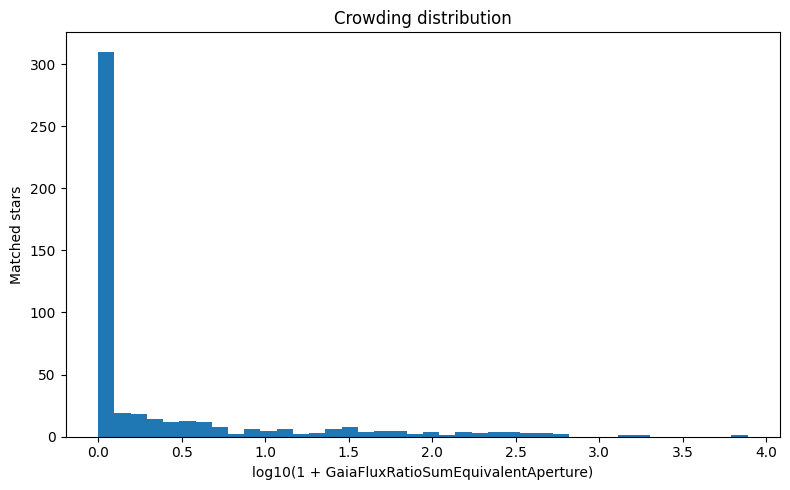

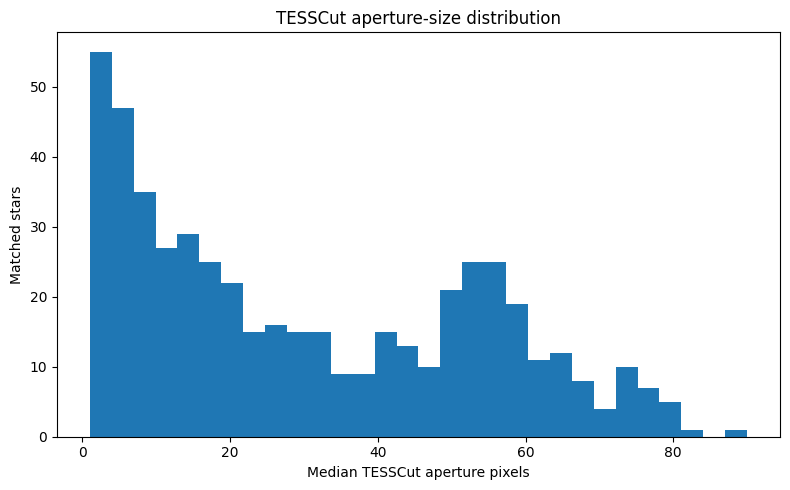

In [7]:
PRIMARY_CROWDING_METRIC = "GaiaFluxRatioSumEquivalentAperture"

if (
    PRIMARY_CROWDING_METRIC not in crowding.columns
    or crowding[PRIMARY_CROWDING_METRIC].notna().sum() < 100
):
    PRIMARY_CROWDING_METRIC = "GaiaFluxRatioSum1Pix"

print("Primary crowding metric:", PRIMARY_CROWDING_METRIC)

valid = pd.to_numeric(crowding[PRIMARY_CROWDING_METRIC], errors="coerce").dropna()

plt.figure(figsize=(8, 5))
plt.hist(np.log10(1.0 + valid), bins=40)
plt.xlabel(f"log10(1 + {PRIMARY_CROWDING_METRIC})")
plt.ylabel("Matched stars")
plt.title("Crowding distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(crowding["TESSCutAperturePixelsMedian"].dropna(), bins=30)
plt.xlabel("Median TESSCut aperture pixels")
plt.ylabel("Matched stars")
plt.title("TESSCut aperture-size distribution")
plt.tight_layout()
plt.show()

## 8. Load the matched feature table

The crowding analysis uses the existing matched SPOC--TESSCut feature table so that the crowding tests remain tied to the same representations used in the controlled classification experiment.

In [8]:
if not SPOC_TESSCut_FEATURE_FILE_QC.exists():
    raise FileNotFoundError(
        f"Matched feature file not found: {SPOC_TESSCut_FEATURE_FILE_QC}"
    )

features = pd.read_parquet(SPOC_TESSCut_FEATURE_FILE_QC)
feature_prov_col = resolve_provenance_column(features)

features = features.copy()
features["VSXId"] = features["VSXId"].astype(str)
features["_Provenance"] = features[feature_prov_col].map(normalize_provenance)

print(f"Feature table: {len(features):,} rows x {len(features.columns)} columns")
display(features["_Provenance"].value_counts())

Feature table: 1,012 rows x 61 columns


_Provenance
SPOC       506
TESSCut    506
Name: count, dtype: int64

## 9. Reproduce the matched SPOC–TESSCut RF predictions

The classifier uses the canonical 39-predictor specification, excluding `ProvenanceScore`, and reproduces the controlled matched-star baseline before crowding is analyzed.

The executed baseline contains 506 matched stars, with 354 training stars and 152 held-out stars. SPOC accuracy is **0.7632** and TESSCut accuracy is **0.6316**; balanced accuracy is **0.5707** for SPOC and **0.3868** for TESSCut. All canonical baseline checks are within the specified tolerances.

In [9]:
MODEL_FEATURE_COLUMNS = [
    "QualityScore", "OriginalFluxMedian", "OriginalFluxStd",
    "CadenceCount", "TimeSpanDays", "MedianCadenceDays", "FluxStd",
    "FluxMedian", "FluxMad", "FluxP05", "FluxP90", "FluxP95", "FluxIqr",
    "FluxAmplitude", "FluxPercentAmplitude95To5", "FluxSkewness",
    "FluxKurtosis", "TailAsymmetry", "TailRatio", "EtaVonNeumann",
    "MaxAbsSlope", "MedianAbsSuccessiveDiff", "FractionBeyond1Std",
    "FractionBeyond2Std", "LsBestPeriod", "LsMaxPower",
    "LsFalseAlarmProbability", "LsPeriod2", "LsPeriod3",
    "LsPeakPowerGap12", "LsPeakPowerGap23", "LsPowerRatio21",
    "LsPowerRatio31", "LsPeriodRatio21", "LsPeriodRatio31",
    "PhaseCurveStd", "PhasePeakPhase", "PhaseTroughPhase",
    "PhasePeakToTroughPhaseDelta",
]

missing = sorted(set(MODEL_FEATURE_COLUMNS) - set(features.columns))
if missing:
    raise ValueError(f"Feature table missing controlled-model columns: {missing}")

assert len(MODEL_FEATURE_COLUMNS) == 39
assert "ProvenanceScore" not in MODEL_FEATURE_COLUMNS
print("Canonical model feature count:", len(MODEL_FEATURE_COLUMNS))
print("ProvenanceScore excluded:", "ProvenanceScore" not in MODEL_FEATURE_COLUMNS)


def provenance_features(name):
    df = features[features["_Provenance"] == name].copy()
    counts = df.groupby("VSXId").size()
    unique_ids = counts.index[counts == 1]
    return (
        df[df["VSXId"].isin(unique_ids)]
        .set_index("VSXId", drop=False)
        .sort_index()
    )


spoc_features = provenance_features("SPOC")
tc_features = provenance_features("TESSCut")

rf_ids = (
    spoc_features.index
    .intersection(tc_features.index)
    .intersection(pd.Index(crowding["VSXId"].astype(str)))
)

spoc_features = spoc_features.loc[rf_ids]
tc_features = tc_features.loc[rf_ids]

if not (
    spoc_features[TARGET_COLUMN].astype(str).values
    == tc_features[TARGET_COLUMN].astype(str).values
).all():
    raise ValueError("SPOC and TESSCut family labels do not match.")

class_counts = spoc_features[TARGET_COLUMN].astype(str).value_counts()
keep_classes = class_counts[class_counts >= 2].index
keep_ids = spoc_features.index[
    spoc_features[TARGET_COLUMN].astype(str).isin(keep_classes)
].to_numpy()

train_ids, test_ids = train_test_split(
    keep_ids,
    test_size=TEST_SIZE,
    stratify=spoc_features.loc[keep_ids, TARGET_COLUMN],
    random_state=RANDOM_STATE,
)
train_ids = sorted(train_ids)
test_ids = sorted(test_ids)


def train_and_predict(source_df, label):
    train_df = source_df.loc[train_ids]
    test_df = source_df.loc[test_ids]

    X_train = train_df[MODEL_FEATURE_COLUMNS]
    y_train = train_df[TARGET_COLUMN].astype(str)
    X_test = test_df[MODEL_FEATURE_COLUMNS]
    y_test = test_df[TARGET_COLUMN].astype(str)

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    confidence = np.max(model.predict_proba(X_test), axis=1)

    return model, pd.DataFrame({
        "VSXId": test_ids,
        "TrueFamily": y_test.loc[test_ids].values,
        f"{label}Prediction": pred,
        f"{label}Correct": pred == y_test.loc[test_ids].values,
        f"{label}Confidence": confidence,
    })


spoc_model, spoc_test = train_and_predict(spoc_features, "SPOC")
tc_model, tc_test = train_and_predict(tc_features, "TESSCut")

test_results = spoc_test.merge(
    tc_test,
    on=["VSXId", "TrueFamily"],
    how="inner",
)

test_results["OutcomeCategory"] = np.select(
    [
        test_results["SPOCCorrect"] & test_results["TESSCutCorrect"],
        test_results["SPOCCorrect"] & ~test_results["TESSCutCorrect"],
        ~test_results["SPOCCorrect"] & test_results["TESSCutCorrect"],
    ],
    [
        "both_correct",
        "spoc_only_correct",
        "tesscut_only_correct",
    ],
    default="both_wrong",
)

crowding_merge = crowding.copy()
crowding_merge["VSXId"] = crowding_merge["VSXId"].astype(str)

test_results = test_results.merge(crowding_merge, on="VSXId", how="left")
test_results.to_parquet(RF_TEST_RESULTS_FILE, index=False)

print(f"Shared train stars: {len(train_ids):,}")
print(f"Shared test stars: {len(test_ids):,}")

SPOCAccuracy = float(test_results["SPOCCorrect"].mean())
TESSCutAccuracy = float(test_results["TESSCutCorrect"].mean())
SPOCBalancedAccuracy = float(
    balanced_accuracy_score(
        test_results["TrueFamily"],
        test_results["SPOCPrediction"],
    )
)
TESSCutBalancedAccuracy = float(
    balanced_accuracy_score(
        test_results["TrueFamily"],
        test_results["TESSCutPrediction"],
    )
)

print("SPOC accuracy:", f"{SPOCAccuracy:.6f}")
print("TESSCut accuracy:", f"{TESSCutAccuracy:.6f}")
print("SPOC balanced accuracy:", f"{SPOCBalancedAccuracy:.6f}")
print("TESSCut balanced accuracy:", f"{TESSCutBalancedAccuracy:.6f}")

CanonicalBaselineCheckDf = pd.DataFrame([
    {
        "Metric": "matched_star_count",
        "Expected": float(CANONICAL_MATCHED_STAR_COUNT),
        "Observed": float(len(keep_ids)),
        "Tolerance": 0.0,
    },
    {
        "Metric": "test_star_count",
        "Expected": float(CANONICAL_TEST_STAR_COUNT),
        "Observed": float(len(test_ids)),
        "Tolerance": 0.0,
    },
    {
        "Metric": "SPOC_accuracy",
        "Expected": CANONICAL_SPOC_ACCURACY,
        "Observed": SPOCAccuracy,
        "Tolerance": CANONICAL_BASELINE_TOLERANCE,
    },
    {
        "Metric": "SPOC_balanced_accuracy",
        "Expected": CANONICAL_SPOC_BALANCED_ACCURACY,
        "Observed": SPOCBalancedAccuracy,
        "Tolerance": CANONICAL_BASELINE_TOLERANCE,
    },
    {
        "Metric": "TESSCut_accuracy",
        "Expected": CANONICAL_TESSCUT_ACCURACY,
        "Observed": TESSCutAccuracy,
        "Tolerance": CANONICAL_BASELINE_TOLERANCE,
    },
    {
        "Metric": "TESSCut_balanced_accuracy",
        "Expected": CANONICAL_TESSCUT_BALANCED_ACCURACY,
        "Observed": TESSCutBalancedAccuracy,
        "Tolerance": CANONICAL_BASELINE_TOLERANCE,
    },
])

CanonicalBaselineCheckDf["Difference"] = (
    CanonicalBaselineCheckDf["Observed"]
    - CanonicalBaselineCheckDf["Expected"]
)
CanonicalBaselineCheckDf["WithinTolerance"] = (
    CanonicalBaselineCheckDf["Difference"].abs()
    <= CanonicalBaselineCheckDf["Tolerance"]
)

print("Canonical matched-baseline check:")
display(CanonicalBaselineCheckDf)

if not CanonicalBaselineCheckDf["WithinTolerance"].all():
    raise RuntimeError(
        "Crowding notebook does not reproduce the current canonical "
        "SPOC--TESSCut matched baseline. Stop before interpreting "
        "crowding/aperture results."
    )

CanonicalBaselineCheckDf.to_csv(
    OUTPUT_DIR / "canonical_matched_baseline_check.csv",
    index=False,
)

display(test_results["OutcomeCategory"].value_counts())


Canonical model feature count: 39
ProvenanceScore excluded: True
Shared train stars: 354
Shared test stars: 152
SPOC accuracy: 0.763158
TESSCut accuracy: 0.631579
SPOC balanced accuracy: 0.570680
TESSCut balanced accuracy: 0.386845
Canonical matched-baseline check:


,Metric,Expected,Observed,Tolerance,Difference,WithinTolerance
0,matched_star_count,506.000000,506.000000,0.0000,0.000000,True
1,test_star_count,152.000000,152.000000,0.0000,0.000000,True
2,SPOC_accuracy,0.763158,0.763158,0.0005,0.000000,True
3,SPOC_balanced_accuracy,0.571000,0.570680,0.0005,-0.000320,True
4,TESSCut_accuracy,0.631579,0.631579,0.0005,0.000000,True
5,TESSCut_balanced_accuracy,0.387000,0.386845,0.0005,-0.000155,True


OutcomeCategory
both_correct            85
spoc_only_correct       31
both_wrong              25
tesscut_only_correct    11
Name: count, dtype: int64

## 10. Performance gap across crowding quartiles

The 148 held-out stars with finite primary crowding values are divided into four equal-size quartiles of 37 stars.

The SPOC-minus-TESSCut accuracy gap is **0.1351** in each of Q1--Q3 and **0.1081** in Q4. The balanced-accuracy gap is **0.3912** in Q1 and **0.2731** in Q4, with non-monotonic intermediate values. The performance gap therefore does **not** increase with crowding in this held-out sample.

/home/jamesliang/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/jamesliang/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/jamesliang/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/jamesliang/.local/lib/python3.13/site-packages/sklearn/metrics/_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,CrowdingQuartile,Stars,CrowdingMedian,SPOCAccuracy,TESSCutAccuracy,AccuracyGap_SPOC_minus_TESSCut,SPOCBalancedAccuracy,TESSCutBalancedAccuracy,BalancedAccuracyGap_SPOC_minus_TESSCut
0,Q1 least crowded,37,0.000060,0.891892,0.756757,0.135135,0.703297,0.312088,0.391209
1,Q2,37,0.010204,0.729730,0.594595,0.135135,0.543750,0.432986,0.110764
2,Q3,37,0.218336,0.621622,0.486486,0.135135,0.480060,0.323810,0.156250
3,Q4 most crowded,37,19.752412,0.810811,0.702703,0.108108,0.680556,0.407407,0.273148


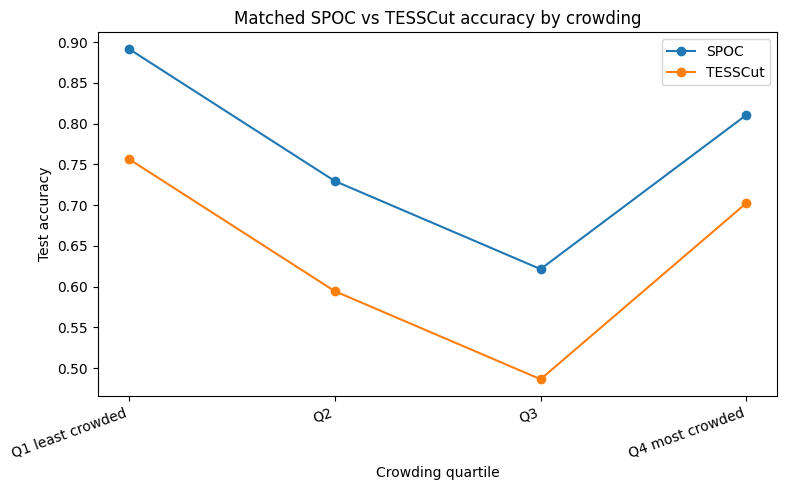

In [10]:
analysis_test = test_results.copy()
analysis_test["_Crowding"] = pd.to_numeric(
    analysis_test[PRIMARY_CROWDING_METRIC],
    errors="coerce",
)
analysis_test = analysis_test[np.isfinite(analysis_test["_Crowding"])].copy()

analysis_test["CrowdingQuartile"] = pd.qcut(
    analysis_test["_Crowding"].rank(method="first"),
    4,
    labels=["Q1 least crowded", "Q2", "Q3", "Q4 most crowded"],
)

rows = []
for quartile, group in analysis_test.groupby("CrowdingQuartile", observed=False):
    spoc_acc = float(group["SPOCCorrect"].mean())
    tc_acc = float(group["TESSCutCorrect"].mean())
    spoc_bal = float(
        balanced_accuracy_score(
            group["TrueFamily"],
            group["SPOCPrediction"],
        )
    )
    tc_bal = float(
        balanced_accuracy_score(
            group["TrueFamily"],
            group["TESSCutPrediction"],
        )
    )

    rows.append({
        "CrowdingQuartile": str(quartile),
        "Stars": len(group),
        "CrowdingMedian": float(group["_Crowding"].median()),
        "SPOCAccuracy": spoc_acc,
        "TESSCutAccuracy": tc_acc,
        "AccuracyGap_SPOC_minus_TESSCut": spoc_acc - tc_acc,
        "SPOCBalancedAccuracy": spoc_bal,
        "TESSCutBalancedAccuracy": tc_bal,
        "BalancedAccuracyGap_SPOC_minus_TESSCut": spoc_bal - tc_bal,
    })

quartile_performance = pd.DataFrame(rows)
display(quartile_performance)

quartile_performance.to_csv(
    OUTPUT_DIR / "accuracy_by_crowding_quartile.csv",
    index=False,
)

plt.figure(figsize=(8, 5))
x = np.arange(len(quartile_performance))
plt.plot(x, quartile_performance["SPOCAccuracy"], marker="o", label="SPOC")
plt.plot(x, quartile_performance["TESSCutAccuracy"], marker="o", label="TESSCut")
plt.xticks(x, quartile_performance["CrowdingQuartile"], rotation=20, ha="right")
plt.ylabel("Test accuracy")
plt.xlabel("Crowding quartile")
plt.title("Matched SPOC vs TESSCut accuracy by crowding")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Direct failure-pattern test

The direct failure-pattern comparison contrasts stars classified correctly only by SPOC with stars classified correctly by both products.

The median primary crowding metric is **0.0363** for `spoc_only_correct` stars and **0.0256** for `both_correct` stars. The two-sided Mann--Whitney test gives **p = 0.9404**, providing no evidence of a crowding difference between these two outcome groups.

In [11]:
outcome_crowding = (
    analysis_test
    .groupby("OutcomeCategory")["_Crowding"]
    .agg(["count", "median", "mean"])
    .sort_values("median")
)
display(outcome_crowding)

a = analysis_test.loc[
    analysis_test["OutcomeCategory"] == "spoc_only_correct",
    "_Crowding",
].dropna()

b = analysis_test.loc[
    analysis_test["OutcomeCategory"] == "both_correct",
    "_Crowding",
].dropna()

if len(a) >= 5 and len(b) >= 5:
    mw = mannwhitneyu(a, b, alternative="two-sided")
    print("spoc_only_correct vs both_correct")
    print("U =", float(mw.statistic))
    print("p =", float(mw.pvalue))
    print("Median spoc_only_correct =", float(a.median()))
    print("Median both_correct =", float(b.median()))
else:
    print("Not enough stars for Mann–Whitney test.")

,count,median,mean
OutcomeCategory,,,
both_correct,83,0.025551,16.250984
spoc_only_correct,30,0.036317,21.990451
tesscut_only_correct,11,0.036407,7.444324
both_wrong,24,0.168220,9.518663


spoc_only_correct vs both_correct
U = 1233.0
p = 0.9403895522954713
Median spoc_only_correct = 0.0363167670485888
Median both_correct = 0.02555104025785713


## 12. Overall SPOC–TESSCut feature disagreement vs crowding

For each retained model feature, the absolute SPOC--TESSCut difference is scaled by that feature's paired-sample IQR. The median scaled difference across features defines the dimensionless per-star summary `RobustFeatureDistance_SPOC_TESSCut`.

Across 491 stars with finite values, feature disagreement is positively associated with crowding: **Spearman $\rho = 0.2278$, $p = 3.36\times10^{-7}$**. Thus, more crowded fields are associated with larger differences between the SPOC and TESSCut feature representations, even though the held-out classification gap does not increase across crowding quartiles.

Crowding vs robust SPOC–TESSCut feature distance
N = 491
Spearman rho = 0.22780517165320938
p = 3.3573382688631554e-07


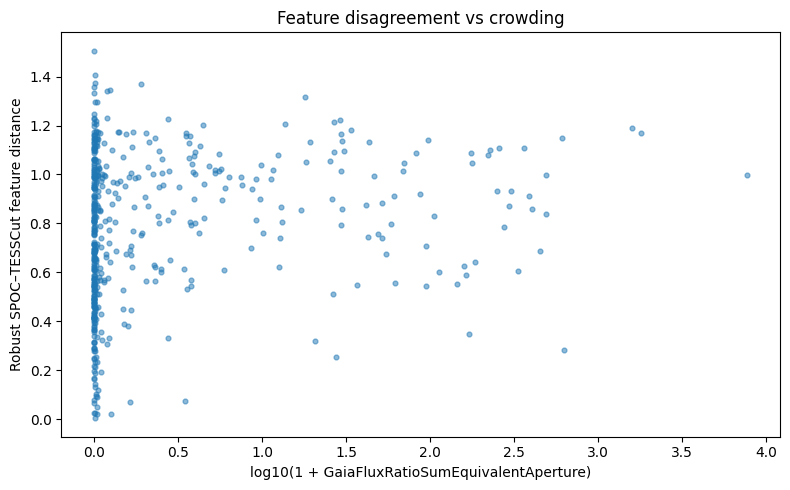

In [12]:
pair_ids = spoc_features.index.intersection(tc_features.index)

components = {}
for feature in MODEL_FEATURE_COLUMNS:
    q = pd.to_numeric(spoc_features.loc[pair_ids, feature], errors="coerce")
    t = pd.to_numeric(tc_features.loc[pair_ids, feature], errors="coerce")
    combined = pd.concat([q, t])
    iqr = combined.quantile(0.75) - combined.quantile(0.25)

    if np.isfinite(iqr) and iqr > 0:
        components[feature] = (q - t).abs() / iqr

component_df = pd.DataFrame(components, index=pair_ids)

feature_distance = (
    component_df.median(axis=1, skipna=True)
    .rename("RobustFeatureDistance_SPOC_TESSCut")
    .reset_index()
    .rename(columns={"index": "VSXId"})
)
feature_distance["VSXId"] = feature_distance["VSXId"].astype(str)

feature_crowding = feature_distance.merge(
    crowding_merge[["VSXId", PRIMARY_CROWDING_METRIC]],
    on="VSXId",
    how="inner",
)

cx = pd.to_numeric(feature_crowding[PRIMARY_CROWDING_METRIC], errors="coerce")
fy = pd.to_numeric(
    feature_crowding["RobustFeatureDistance_SPOC_TESSCut"],
    errors="coerce",
)
mask = np.isfinite(cx) & np.isfinite(fy)

overall_feature_distance_rho, overall_feature_distance_p = spearmanr(
    cx[mask],
    fy[mask],
)

print("Crowding vs robust SPOC–TESSCut feature distance")
print("N =", int(mask.sum()))
print("Spearman rho =", float(overall_feature_distance_rho))
print("p =", float(overall_feature_distance_p))

feature_crowding.to_parquet(
    OUTPUT_DIR / "feature_distance_vs_crowding.parquet",
    index=False,
)

plt.figure(figsize=(8, 5))
plt.scatter(np.log10(1 + cx[mask]), fy[mask], s=12, alpha=0.5)
plt.xlabel(f"log10(1 + {PRIMARY_CROWDING_METRIC})")
plt.ylabel("Robust SPOC–TESSCut feature distance")
plt.title("Feature disagreement vs crowding")
plt.tight_layout()
plt.show()

## 13. Feature-level and aperture associations

Individual-feature tests identify the strongest associations between crowding and absolute SPOC--TESSCut feature differences. The largest observed correlation is for `MedianAbsSuccessiveDiff` (**$\rho = 0.4398$**), followed by `EtaVonNeumann` (**$\rho = 0.3532$**) and `OriginalFluxStd` (**$\rho = 0.2943$**).

The robust feature-distance summary is also associated with aperture size and the combined crowding-times-aperture proxy:

- median TESSCut aperture pixels: **$\rho = -0.289$, $p = 3.49\times10^{-11}$**;
- primary crowding metric: **$\rho = 0.228$, $p = 3.36\times10^{-7}$**;
- crowding × aperture pixels: **$\rho = 0.201$, $p = 7.12\times10^{-6}$**.

The per-feature tests are exploratory because multiple features are examined.

In [13]:
crowding_by_id = crowding_merge.set_index("VSXId")[PRIMARY_CROWDING_METRIC]

per_feature_rows = []
for feature in MODEL_FEATURE_COLUMNS:
    q = pd.to_numeric(spoc_features.loc[pair_ids, feature], errors="coerce")
    t = pd.to_numeric(tc_features.loc[pair_ids, feature], errors="coerce")
    d = (q - t).abs()
    c = pd.to_numeric(crowding_by_id.reindex(pair_ids), errors="coerce")
    valid = np.isfinite(d) & np.isfinite(c)

    if valid.sum() >= 30:
        r, p = spearmanr(c[valid], d[valid])
        per_feature_rows.append({
            "Feature": feature,
            "N": int(valid.sum()),
            "SpearmanRhoAbsDifferenceVsCrowding": float(r),
            "PValue": float(p),
        })

per_feature = pd.DataFrame(per_feature_rows)
if len(per_feature):
    per_feature["AbsRho"] = per_feature["SpearmanRhoAbsDifferenceVsCrowding"].abs()
    per_feature = per_feature.sort_values("AbsRho", ascending=False)
    display(per_feature.head(15))
    per_feature.to_csv(
        OUTPUT_DIR / "individual_feature_difference_crowding_spearman.csv",
        index=False,
    )

aperture_feature = feature_distance.merge(
    crowding_merge[
        ["VSXId", PRIMARY_CROWDING_METRIC, "TESSCutAperturePixelsMedian"]
    ],
    on="VSXId",
    how="inner",
)

aperture_feature["CrowdingTimesAperture"] = (
    pd.to_numeric(aperture_feature[PRIMARY_CROWDING_METRIC], errors="coerce")
    * pd.to_numeric(aperture_feature["TESSCutAperturePixelsMedian"], errors="coerce")
)

print("\nSeparate aperture/crowding association tests:")

for metric in [
    "TESSCutAperturePixelsMedian",
    PRIMARY_CROWDING_METRIC,
    "CrowdingTimesAperture",
]:
    x = pd.to_numeric(aperture_feature[metric], errors="coerce")
    y = pd.to_numeric(
        aperture_feature["RobustFeatureDistance_SPOC_TESSCut"],
        errors="coerce",
    )
    valid = np.isfinite(x) & np.isfinite(y)

    if valid.sum() >= 30:
        r, p = spearmanr(x[valid], y[valid])
        print(
            f"{metric} vs feature distance: "
            f"N={int(valid.sum())}, rho={r:.3f}, p={p:.3g}"
        )

/tmp/ipykernel_587142/2998856885.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = spearmanr(c[valid], d[valid])


,Feature,N,SpearmanRhoAbsDifferenceVsCrowding,PValue,AbsRho
21,MedianAbsSuccessiveDiff,491,0.439819,1.209882e-24,0.439819
19,EtaVonNeumann,491,0.353168,7.196015e-16,0.353168
2,OriginalFluxStd,491,0.294310,2.876442e-11,0.294310
18,TailRatio,491,0.291487,4.518060e-11,0.291487
8,FluxMad,491,0.210664,2.488610e-06,0.210664
12,FluxIqr,491,0.196510,1.153911e-05,0.196510
26,LsFalseAlarmProbability,491,0.183344,4.370321e-05,0.183344
1,OriginalFluxMedian,491,0.167413,1.941567e-04,0.167413
3,CadenceCount,491,-0.162515,2.992015e-04,0.162515
0,QualityScore,491,-0.155911,5.259570e-04,0.155911



Separate aperture/crowding association tests:
TESSCutAperturePixelsMedian vs feature distance: N=506, rho=-0.289, p=3.49e-11
GaiaFluxRatioSumEquivalentAperture vs feature distance: N=491, rho=0.228, p=3.36e-07
CrowdingTimesAperture vs feature distance: N=491, rho=0.201, p=7.12e-06


## 14. Conclusion

The crowding control produces two distinct findings.

First, local crowding is associated with larger SPOC--TESSCut feature disagreement. The robust feature-distance measure has a positive Spearman correlation with the primary crowding metric ($\rho=0.2278$, $p=3.36\times10^{-7}$), and several individual variability/scatter features show stronger associations.

Second, the classification-performance evidence does not show that crowding explains the SPOC--TESSCut performance gap. The accuracy gap decreases from **0.1351** in the least-crowded quartile to **0.1081** in the most-crowded quartile, the balanced-accuracy gap also decreases between those endpoints, and the direct `spoc_only_correct` versus `both_correct` crowding comparison is null ($p=0.9404$).

The implemented Gaia/aperture proxies therefore identify crowding-related representation differences but do not account for the matched SPOC--TESSCut classification advantage. This association analysis does not isolate a unique causal mechanism.

In [14]:
summary_rows = []

if len(quartile_performance):
    first = quartile_performance.iloc[0]
    last = quartile_performance.iloc[-1]
    summary_rows.append({
        "Metric": "SPOC-TESSCut accuracy gap, least crowded quartile",
        "Value": float(first["AccuracyGap_SPOC_minus_TESSCut"]),
    })
    summary_rows.append({
        "Metric": "SPOC-TESSCut accuracy gap, most crowded quartile",
        "Value": float(last["AccuracyGap_SPOC_minus_TESSCut"]),
    })
    summary_rows.append({
        "Metric": "Change in accuracy gap Q4-Q1",
        "Value": float(
            last["AccuracyGap_SPOC_minus_TESSCut"]
            - first["AccuracyGap_SPOC_minus_TESSCut"]
        ),
    })

    summary_rows.append({
        "Metric": "SPOC-TESSCut balanced-accuracy gap, least crowded quartile",
        "Value": float(first["BalancedAccuracyGap_SPOC_minus_TESSCut"]),
    })
    summary_rows.append({
        "Metric": "SPOC-TESSCut balanced-accuracy gap, most crowded quartile",
        "Value": float(last["BalancedAccuracyGap_SPOC_minus_TESSCut"]),
    })
    summary_rows.append({
        "Metric": "Change in balanced-accuracy gap Q4-Q1",
        "Value": float(
            last["BalancedAccuracyGap_SPOC_minus_TESSCut"]
            - first["BalancedAccuracyGap_SPOC_minus_TESSCut"]
        ),
    })

summary_rows.append({
    "Metric": "Spearman crowding vs robust feature distance",
    "Value": float(overall_feature_distance_rho),
})
summary_rows.append({
    "Metric": "Spearman p-value",
    "Value": float(overall_feature_distance_p),
})

summary = pd.DataFrame(summary_rows)
display(summary)

summary.to_csv(
    OUTPUT_DIR / "primary_crowding_experiment_summary.csv",
    index=False,
)

print("All outputs saved under:")
print(OUTPUT_DIR)

,Metric,Value
0,"SPOC-TESSCut accuracy gap, least crowded quartile",1.351351e-01
1,"SPOC-TESSCut accuracy gap, most crowded quartile",1.081081e-01
2,Change in accuracy gap Q4-Q1,-2.702703e-02
3,"SPOC-TESSCut balanced-accuracy gap, least crow...",3.912088e-01
4,"SPOC-TESSCut balanced-accuracy gap, most crowd...",2.731481e-01
5,Change in balanced-accuracy gap Q4-Q1,-1.180606e-01
6,Spearman crowding vs robust feature distance,2.278052e-01
7,Spearman p-value,3.357338e-07


All outputs saved under:
/data/projects/TESS-research/summary/spoc_tesscut_crowding


## Section 8 result summary

The canonical baseline check passes before the crowding/aperture results are evaluated. Crowding-quartile performance, the direct outcome-group comparison, and the feature-distance association provide complementary tests.

The executed results show a statistically significant association between crowding and SPOC--TESSCut feature disagreement, but no monotonic increase in the held-out performance gap with crowding. Aperture-size associations are reported separately from Gaia crowding associations, and the combined crowding-times-aperture quantity remains a secondary diagnostic.

## Export the SPOC crowding-gap figure from saved results

The following cell reads the saved quartile CSV and exports the accuracy and balanced-accuracy gap figure. It does not query Gaia, fit models, recalculate crowding metrics, or overwrite the analysis tables. Re-execution overwrites only the PNG figure.

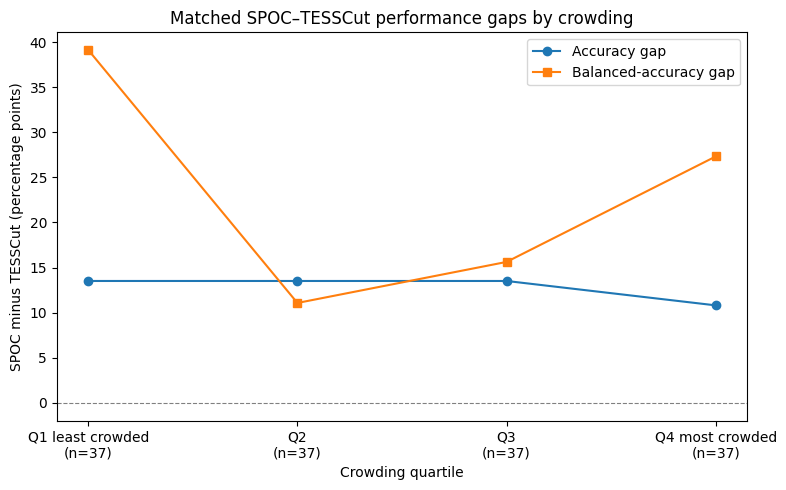

Source: /data/projects/TESS-research/summary/spoc_tesscut_crowding/accuracy_by_crowding_quartile.csv
Saved figure: /data/projects/TESS-research/summary/spoc_tesscut_crowding/crowding_quartile_gaps_spoc_section8.png


,CrowdingQuartile,Stars,AccuracyGap_SPOC_minus_TESSCut,BalancedAccuracyGap_SPOC_minus_TESSCut
0,Q1 least crowded,37,0.135135,0.391209
1,Q2,37,0.135135,0.110764
2,Q3,37,0.135135,0.156250
3,Q4 most crowded,37,0.108108,0.273148


In [1]:
# Run only this cell to plot saved results; no Gaia queries or model fitting.
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

SAVED_RESULTS_DIR = Project_Root / "summary" / "spoc_tesscut_crowding"
QUARTILE_CSV = SAVED_RESULTS_DIR / "accuracy_by_crowding_quartile.csv"
FIGURE_FILE = SAVED_RESULTS_DIR / "crowding_quartile_gaps_spoc_section8.png"

if not QUARTILE_CSV.is_file():
    raise FileNotFoundError(f"Saved quartile results not found: {QUARTILE_CSV}. Locate the CSV from the previous run and update SAVED_RESULTS_DIR.")

saved_quartiles = pd.read_csv(QUARTILE_CSV)
required = ["CrowdingQuartile", "Stars", "AccuracyGap_SPOC_minus_TESSCut", "BalancedAccuracyGap_SPOC_minus_TESSCut"]
missing = [column for column in required if column not in saved_quartiles.columns]
if missing:
    raise ValueError(f"Saved CSV is missing required columns: {missing}")
if len(saved_quartiles) != 4 or saved_quartiles[required].isna().any().any():
    raise ValueError("Expected four complete crowding-quartile rows in the saved CSV.")

# Preserve the quartile order and metric values saved by the analysis.
x = range(len(saved_quartiles))
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, 100 * saved_quartiles["AccuracyGap_SPOC_minus_TESSCut"], marker="o", label="Accuracy gap")
ax.plot(x, 100 * saved_quartiles["BalancedAccuracyGap_SPOC_minus_TESSCut"], marker="s", label="Balanced-accuracy gap")
labels = [f"{q}\n(n={int(count)})" for q, count in zip(saved_quartiles["CrowdingQuartile"], saved_quartiles["Stars"])]
ax.set_xticks(list(x), labels)
ax.set_xlabel("Crowding quartile")
ax.set_ylabel("SPOC minus TESSCut (percentage points)")
ax.set_title("Matched SPOC–TESSCut performance gaps by crowding")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_FILE, dpi=300, bbox_inches="tight")
plt.show()
print(f"Source: {QUARTILE_CSV}")
print(f"Saved figure: {FIGURE_FILE}")
display(saved_quartiles[required])
